# Part 5 - GRU Sequence Models on CIFAR-10
This notebook compares two sequence representations (row-wise and patch-wise) and plots combined curves like Khoa's section.

In [1]:
import time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [3]:
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
NUM_CLASSES = 10
NUM_WORKERS = 2
PATCH = 4


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_ds = torchvision.datasets.CIFAR10(
    "./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    "./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))
print("Classes:", train_ds.classes)


100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


Train size: 50000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
def to_row_sequence(x):
    B, C, H, W = x.shape
    return x.permute(0, 2, 1, 3).contiguous().view(B, H, C * W)

def to_patch_sequence(x, p=4):
    B, C, H, W = x.shape
    assert H % p == 0 and W % p == 0
    h, w = H // p, W // p
    x = x.view(B, C, h, p, w, p).permute(0, 2, 4, 1, 3, 5).contiguous()
    tokens = x.view(B, h * w, C * p * p)
    return tokens


In [6]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1, num_classes=10):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.fc(last)


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device, mode="row"):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if mode == "row":
            seq = to_row_sequence(imgs)
        else:
            seq = to_patch_sequence(imgs, p=PATCH)

        optimizer.zero_grad()
        out = model(seq)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        pred = out.argmax(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, mode="row"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if mode == "row":
            seq = to_row_sequence(imgs)
        else:
            seq = to_patch_sequence(imgs, p=PATCH)

        out = model(seq)
        loss = criterion(out, labels)

        total_loss += loss.item() * imgs.size(0)
        pred = out.argmax(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


In [8]:
def run(mode="row"):
    if mode == "row":
        input_size = 3 * 32
    else:
        input_size = 3 * (PATCH * PATCH)

    model = GRUClassifier(input_size=input_size, hidden_size=128).to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    start = time.time()

    for e in range(EPOCHS):
        tl, ta = train_one_epoch(model, train_loader, crit, opt, device, mode)
        vl, va = evaluate(model, test_loader, crit, device, mode)

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["test_loss"].append(vl)
        history["test_acc"].append(va)

        print(
            f"{mode} | Epoch {e+1}/{EPOCHS} | "
            f"Train Loss: {tl:.4f} | Train Acc: {ta:.4f} | "
            f"Test Loss: {vl:.4f} | Test Acc: {va:.4f}"
        )

    total_time = time.time() - start

    result = {
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_test_loss": history["test_loss"][-1],
        "final_test_acc": history["test_acc"][-1],
        "train_time_sec": total_time,
        "epochs": EPOCHS,
        "mode": mode
    }
    return result, history


In [9]:
print("Training GRU (row-wise)")
res_row, hist_row = run("row")

print("\nTraining GRU (patch-wise)")
res_patch, hist_patch = run("patch")


Training GRU (row-wise)
row | Epoch 1/10 | Train Loss: 1.7902 | Train Acc: 0.3400 | Test Loss: 1.5934 | Test Acc: 0.4142
row | Epoch 2/10 | Train Loss: 1.5089 | Train Acc: 0.4481 | Test Loss: 1.4414 | Test Acc: 0.4709
row | Epoch 3/10 | Train Loss: 1.3669 | Train Acc: 0.5033 | Test Loss: 1.3222 | Test Acc: 0.5169
row | Epoch 4/10 | Train Loss: 1.2674 | Train Acc: 0.5428 | Test Loss: 1.2765 | Test Acc: 0.5341
row | Epoch 5/10 | Train Loss: 1.1986 | Train Acc: 0.5696 | Test Loss: 1.2223 | Test Acc: 0.5579
row | Epoch 6/10 | Train Loss: 1.1377 | Train Acc: 0.5884 | Test Loss: 1.2149 | Test Acc: 0.5633
row | Epoch 7/10 | Train Loss: 1.0886 | Train Acc: 0.6104 | Test Loss: 1.1775 | Test Acc: 0.5793
row | Epoch 8/10 | Train Loss: 1.0477 | Train Acc: 0.6242 | Test Loss: 1.1847 | Test Acc: 0.5818
row | Epoch 9/10 | Train Loss: 1.0072 | Train Acc: 0.6388 | Test Loss: 1.1734 | Test Acc: 0.5873
row | Epoch 10/10 | Train Loss: 0.9737 | Train Acc: 0.6509 | Test Loss: 1.1547 | Test Acc: 0.5933

Trai

In [10]:
def plot_comparison(hist1, hist2, label1="GRU Row-wise", label2="GRU Patch-wise"):
    epochs = range(1, len(hist1["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["train_loss"], label=label1)
    plt.plot(epochs, hist2["train_loss"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["test_loss"], label=label1)
    plt.plot(epochs, hist2["test_loss"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Test Loss by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["train_acc"], label=label1)
    plt.plot(epochs, hist2["train_acc"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, hist1["test_acc"], label=label1)
    plt.plot(epochs, hist2["test_acc"], label=label2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Test Accuracy by Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()


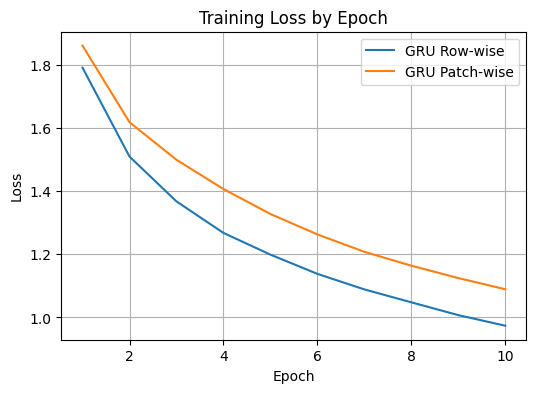

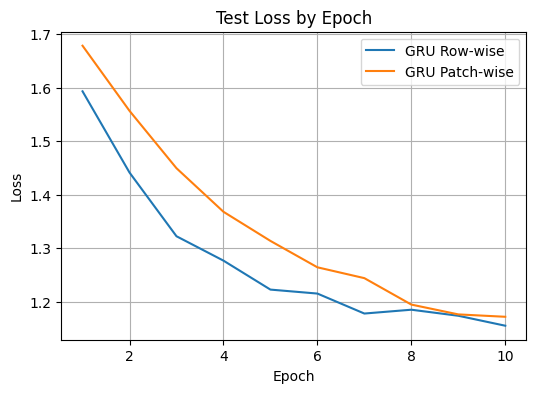

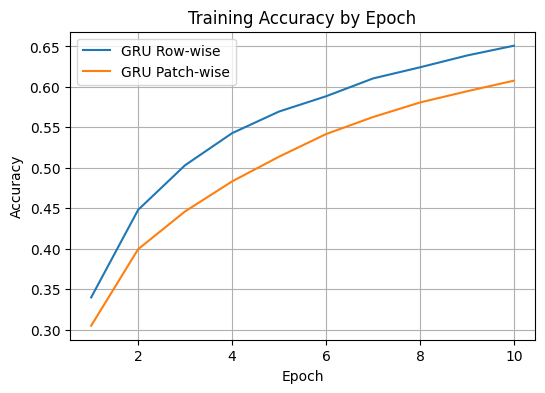

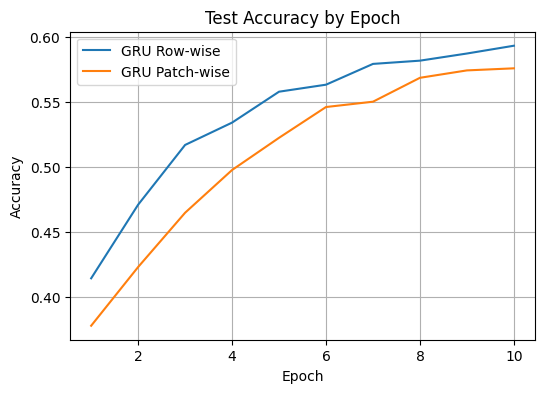

In [11]:
plot_comparison(hist_row, hist_patch, "GRU Row-wise", "GRU Patch-wise")


In [12]:
print("\nTable-ready results (same format as Khoa)")
print("-" * 120)
print(f"{'Model':30s} {'Train Accuracy':15s} {'Test Accuracy':15s} {'Train Loss':12s} {'Test Loss':12s} {'Training Time (s)':18s}")
print("-" * 120)

print(
    f"{'GRU (row-wise)':30s} "
    f"{res_row['final_train_acc']:.4f}           "
    f"{res_row['final_test_acc']:.4f}           "
    f"{res_row['final_train_loss']:.4f}       "
    f"{res_row['final_test_loss']:.4f}       "
    f"{res_row['train_time_sec']:.2f}"
)

print(
    f"{'GRU (patch-wise)':30s} "
    f"{res_patch['final_train_acc']:.4f}           "
    f"{res_patch['final_test_acc']:.4f}           "
    f"{res_patch['final_train_loss']:.4f}       "
    f"{res_patch['final_test_loss']:.4f}       "
    f"{res_patch['train_time_sec']:.2f}"
)



Table-ready results (same format as Khoa)
------------------------------------------------------------------------------------------------------------------------
Model                          Train Accuracy  Test Accuracy   Train Loss   Test Loss    Training Time (s) 
------------------------------------------------------------------------------------------------------------------------
GRU (row-wise)                 0.6509           0.5933           0.9737       1.1547       144.41
GRU (patch-wise)               0.6077           0.5759           1.0891       1.1714       143.25
